<h1 style="text-align:center;">Two-armed Bernoulli bandit</h1>

## Summary

* [**1. Problem Statement**](#0)
* [**2. ETC : Explore Then Commit**](#1)
    * [2.1. Empirical expectation](#1_1)
    * [2.2. Offline optimal policy](#1_2)
* [**3. Upper bound of the ETC expected regret**](#2)
* [**4. UCB : Upper Confidence Bound**](#3)
* [**5. Comparaison UCB vs ETC**](#3)

<a id='0'></a>
# 1. Problem statement :

The aim of this project is to study the empirical regret. Consider a two-armed Bernoulli bandit with means $\mu_1 = \tfrac{1}{2}$ and $\mu_2 = \tfrac{1}{2} - \Delta$.


At each time step $t$, the agent chooses an arm and receives a binary reward
$X_t \in \{0,1\}$.

Each arm $i \in \{1,2\}$ follows a Bernoulli distribution with unknown mean
$\mu_i = \mathbb{E}[X_{i,t}]$.  


Let

$$
\bar{R}_T = \sum_{t=1}^{T} \Delta_{A_t},
$$

- $A_t$ denotes the **arm chosen at time $t$** : $A_t \in \{1,2\}$
- $\Delta_i$ denotes the *gap* of arm $i$ : $\Delta_i = \mu^* - \mu_i$  (here $\Delta_1 = 0, \qquad \Delta_2 = \Delta$)


Interpretation:

$$
A_t = 1 \;\Rightarrow\; \text{no loss},
\qquad
A_t = 2 \;\Rightarrow\; \text{loss of } \Delta.
$$


*Remark :* $R_T$ is chosen so that $R_T = \mathbb{E}[\bar{R}_T]$.

In [84]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<a id='1'></a>
# 2. ETC : Explore Then Commit

<a id='1_1'></a>
# 2.1 Empirical expectation



ETC splits the horizon $T$ into two phases:

#### Phase 1 — Exploration
- Pull **each arm exactly $m$ times**.
- Total exploration time: $2m$ steps.
- Compute empirical means:
  $$
  \hat{\mu}_i = \frac{1}{m} \sum_{k=1}^{m} X_{i,k}.
  $$

#### Phase 2 — Commit (Exploitation)
- Choose the arm with the highest empirical mean:
  $$
  \hat{i} = \arg\max_i \hat{\mu}_i.
  $$
- Pull this arm for the remaining $T - 2m$ steps.


---


## Empirical expectation


$$
\widehat{\mathbb{E}}[\bar R_T]
=
\frac{1}{n_{\text{sim}}}
\sum_{j=1}^{n_{\text{sim}}}
\Bigg[
m(\Delta_1 + \Delta_2)
+
(T-2m)\Delta_{\hat{i}^{(j)}}
\Bigg].
$$

where : $\hat{i}^{(j)} =\begin{cases}1 & \text{if } \hat{\mu}_1^{(j)} \ge \hat{\mu}_2^{(j)}, \\2 & \text{otherwise}.\end{cases}$

Hence, $\Delta_{\hat{i}^{(j)}}$ is the gap of the arm chosen in the commit phase
of simulation $j$.



In [85]:
# ------------------------------------------------------------
# Function regret ETC
# ------------------------------------------------------------
def regret_etc(
    m: int,
    T: int,
    mu_1: float,
    mu_2: float,
    n_sim: int = 10_000,
) -> float:
    """
    Monte-Carlo estimation of the expected pseudo-regret of an
    This code use p_m in the final formula witch is not observed by the agent so the objectie is to establish the offline optimal policy.

    ------------------------------------------------------------------------
    MATHEMATICAL SETTING
    ------------------------------------------------------------------------
    Horizon:
        T 

    Arms:
        Arm 1 ~ Bernoulli(mu_1)
        Arm 2 ~ Bernoulli(mu_2)

    Let:
        mu* = max(mu_1, mu_2)
        Δ_i = mu* − mu_i

    Pseudo-regret:
        R̄_T = sum_{t=1}^T Δ_{A_t}
             = sum_{t=1}^T (mu* − mu_{A_t})

    ------------------------------------------------------------------------
    PARAMETERS
    ------------------------------------------------------------------------
    m       : exploration parameter (number of pulls per arm)
    T       : time horizon
    mu_1    : true mean of arm 1 (unknown to the agent)
    mu_2    : true mean of arm 2 (unknown to the agent)
    n_sim   : number of Monte-Carlo simulations

    ------------------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------------------
    float
        Monte-Carlo estimate of E[R̄_T].
    """

    if m < 0 or 2 * m > T:
        raise ValueError("m must satisfy 0 ≤ m ≤ T//2")

    mu_star = max(mu_1, mu_2)
    Delta_1 = mu_star - mu_1
    Delta_2 = mu_star - mu_2

    # --------------------------------------------------------------------
    # Exploration phase (vectorised)
    # --------------------------------------------------------------------
    # S_i ~ Binomial(m, mu_i)
    S1 = np.random.binomial(m, mu_1, size=n_sim)
    S2 = np.random.binomial(m, mu_2, size=n_sim)

    if m > 0:
        hat_mu_1 = S1 / m
        hat_mu_2 = S2 / m
    else:
        hat_mu_1 = np.zeros(n_sim)
        hat_mu_2 = np.zeros(n_sim)

    # --------------------------------------------------------------------
    # Decision rule (commit phase)
    # --------------------------------------------------------------------
    commit_arm_1 = hat_mu_1 >= hat_mu_2

    # --------------------------------------------------------------------
    # Regret computation
    # --------------------------------------------------------------------
    # Exploration regret (deterministic across simulations)
    exploration_regret = m * Delta_1 + m * Delta_2

    # Commit regret (depends on the decision)
    commit_regret = np.where(
        commit_arm_1,
        (T - 2*m) * Delta_1,
        (T - 2*m) * Delta_2
    )

    total_regret = exploration_regret + commit_regret

    return float(np.mean(total_regret))

<a id='1_2'></a>
## 2.2 Offline optimal policy 

We are looking for $m^{*}$ s.t :
$$
m^{*}
=
\arg\min_{m \le \frac{T}{2}}
\mathbb{E}\big[ R_T(m) \big].
$$

In [86]:
# ------------------------------------------------------------
# Find best m for ETC (brute force)
# ------------------------------------------------------------
def best_m_etc(
    T: int,
    mu_1: float,
    mu_2: float,
    n_sim: int = 10_000,
):
    """
    Brute-force search over m in {0,...,T//2}.

    Returns
    -------
    m_star : int
        Value of m minimizing the Monte-Carlo estimate of E[R_T(m)].
    m_list : list[tuple]
        List of (m, estimated_regret).
    """

    m_max = T // 2
    m_list = []

    best_m = None
    best_regret = float("inf")

    for m in range(2, m_max + 1):
        r = regret_etc(
            m=m,
            T=T,
            mu_1=mu_1,
            mu_2=mu_2,
            n_sim=n_sim,
        )

        m_list.append((m, r))

        if r < best_regret:
            best_regret = r
            best_m = m

    return best_m, m_list

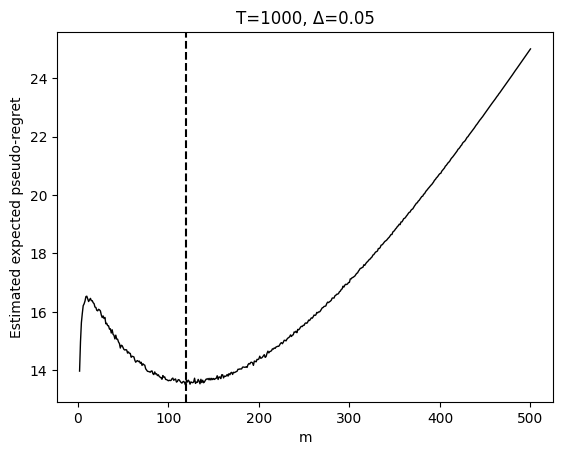

m* = 119


In [ ]:
# Parameters
T = 1000
Delta = 0.05

mu_1 = 0.5
mu_2 = 0.5 - Delta

n_sim = 100_000

m_star, m_list = best_m_etc(
    T=T,
    mu_1=mu_1,
    mu_2=mu_2,
    n_sim=n_sim,
)

m_vals = [x[0] for x in m_list]
regrets = [x[1] for x in m_list]


plt.figure()
plt.plot(m_vals, regrets, color = "black", linewidth = 1)
plt.axvline(m_star, linestyle="--", color = "black")
plt.xlabel("m")
plt.ylabel("Estimated expected pseudo-regret")
plt.title(f"T={T}, Δ={Delta}")
plt.show()

print("m* =", m_star)

<a id='2'></a>
# 3.Upper bound of the ETC expected regret :


The expected pseudo-regret of ETC is

$$
\mathbb{E}[R_T(m)]
=
m\Delta
+
(T-2m)\Delta\, p_m,
$$

where : $p_m = \mathbb{P}(\hat{\mu}_2 \ge \hat{\mu}_1)$




---

### Bounding the error probability

The error event is

$$
\hat{\mu}_2 \ge \hat{\mu}_1,
$$

while in expectation we have

$$
\mu_1 - \mu_2 = \Delta > 0.
$$

Hence the error occurs when statistical fluctuations reverse the order of the empirical means.

Define

$$
Z = (\hat{\mu}_1 - \hat{\mu}_2) - (\mu_1 - \mu_2).
$$

Since empirical averages are computed from bounded Bernoulli variables,
Hoeffding's inequality gives an exponential concentration bound:

$$
\mathbb{P}(\hat{\mu}_2 \ge \hat{\mu}_1)
=
\mathbb{P}(Z \le -\Delta)
\le
\exp\!\left(-\frac{m\Delta^2}{2}\right).
$$

Therefore,

$$
p_m \le \exp\!\left(-\frac{m\Delta^2}{2}\right).
$$

---

### Upper bound of the regret

Injecting this bound into the regret expression yields

$$
\mathbb{E}[R_T(m)]
\le
m\Delta
+
(T-2m)\Delta
\exp\!\left(-\frac{m\Delta^2}{2}\right).
$$


---

### Choice of the exploration length

The term $(T-2m)\Delta\exp\!\left(-\frac{m\Delta^2}{2}\right)$ is linear growth with $T$, so we want to choose $m^*$ s.t :

$$
\exp\!\left(-\frac{m\Delta^2}{2}\right)
\approx
\frac{1}{T}
\;\Rightarrow\;
m
=
\frac{2}{\Delta^2}
\log\!\left(\frac{T\Delta^2}{2}\right).
$$


---

### Resulting theoretical upper bound

Plugging this choice into the previous inequality leads to the classical bound:

$$
R_{\nu}(\mathrm{ETC},T)
\le
\frac{2}{\Delta}
\left[
\log\!\left(\frac{T\Delta^2}{2}\right)+1
\right].
$$


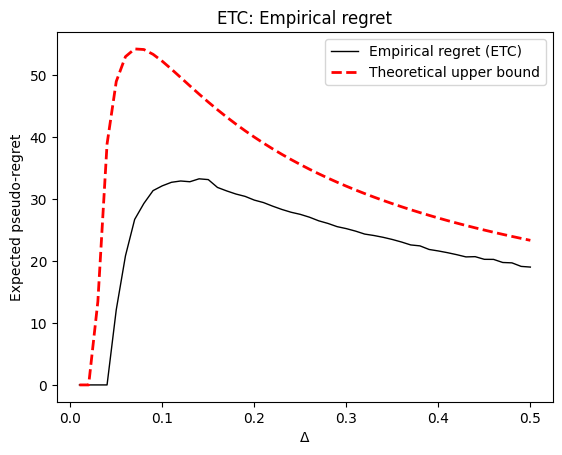

In [88]:
# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
h = 0.01     # Step for Delta variation
N = 100  # number of Monte-Carlo runs per Delta

# Delta grid: vary between 0 and 1/2 with step h
Delta_grid = np.arange(h, 0.5 + 1e-12, h)

# storage
regret_emp = []
upper_bounds = []
m_values = []

# ------------------------------------------------------------
# Main loop over Delta
# ------------------------------------------------------------
for Delta in Delta_grid:
    mu_1 = 0.5
    mu_2 = 0.5 - Delta

    # m(Delta) = (2/Delta^2) log(T Delta^2 / 2)
    # -> must be integer and satisfy 0 <= 2m <= T
    inside = (T * Delta**2) / 2

    # if inside <= 1, log(inside) <= 0 -> formula gives m <= 0
    # we clamp to m=0 in that case (no exploration), consistent with constraint
    if inside <= 1.0:
        m = 0
    else:
        m = int(np.floor((2 / Delta**2) * np.log(inside)))

    # clamp to feasible range
    m = max(0, min(m, T // 2))

    # Monte-Carlo estimate of expected pseudo-regret
    r = regret_etc(m=m, T=T, mu_1=mu_1, mu_2=mu_2, n_sim=N)

    # Theoretical upper bound
    ub = (2 / Delta) * (np.log(inside) + 1)
    ub_plot = max(0.0, ub)

    regret_emp.append(r)
    upper_bounds.append(ub_plot)
    m_values.append(m)

regret_emp = np.array(regret_emp)
upper_bounds = np.array(upper_bounds)
m_values = np.array(m_values)

# ------------------------------------------------------------
# Plot: empirical regret vs upper bound
# ------------------------------------------------------------
plt.figure()
plt.plot(Delta_grid, regret_emp, color="black", linewidth=1, label="Empirical regret (ETC)")
plt.plot(Delta_grid, upper_bounds, color="red", linestyle="--", linewidth=2, label="Theoretical upper bound")
plt.xlabel("Δ")
plt.ylabel("Expected pseudo-regret")
plt.title(f"ETC: Empirical regret")
plt.legend()
plt.show()

<a id='3'></a>
# 4. UCB : Upper Confidence Bound 

### From ETC to UCB


ETC chooses an exploration length $m$, pulls each arm $m$ times, then commits to the empirically best arm for the remaining $T-2m$ steps.

This is not an agent-feasible policy, because the agent does not observe $\Delta$ (or $\mu_1,\mu_2$).

---


The objective is to design a policy that is optimal for the agent, i.e. it uses only observed rewards and automatically balances exploration/exploitation without knowing $\Delta$.

UCB (Upper Confidence Bound) replaces the fixed exploration length $m$ by an adaptive optimism bonus.
At time $t$, for each arm $i$, define
$$
\mathrm{UCB}_i(t)
=
\hat{\mu}_i(t)
+
\sqrt{\frac{2\log t}{N_i(t)}},
$$
where $N_i(t)$ is the number of pulls of arm $i$ up to time $t$.
Then UCB selects
$$
A_t=\arg\max_i \ \mathrm{UCB}_i(t).
$$


In [89]:
# ------------------------------------------------------------
# Function regret UCB
# ------------------------------------------------------------
def regret_ucb(
    T: int,
    mu_1: float,
    mu_2: float,
    n_sim: int = 10_000,
) -> float:
    """
    Monte-Carlo estimation of the expected pseudo-regret of an
    This code use UCB_i during learning to adapt his policy.

    ------------------------------------------------------------------------
    MATHEMATICAL SETTING
    ------------------------------------------------------------------------
    Horizon:
        T 

    Arms: (law unobserved)
        Arm 1 ~ Bernoulli(mu_1)
        Arm 2 ~ Bernoulli(mu_2)

    Let:
        mu* = max(mu_1, mu_2)
        Δ_i = mu* − mu_i

    Pseudo-regret:
        R̄_T = sum_{t=1}^T Δ_{A_t}
             = sum_{t=1}^T (mu* − mu_{A_t})

    ------------------------------------------------------------------------
    PARAMETERS
    ------------------------------------------------------------------------
    m       : exploration parameter (number of pulls per arm)
    T       : time horizon
    mu_1    : true mean of arm 1 (unknown to the agent)
    mu_2    : true mean of arm 2 (unknown to the agent)
    n_sim   : number of Monte-Carlo simulations

    ------------------------------------------------------------------------
    RETURNS
    ------------------------------------------------------------------------
    float
        Monte-Carlo estimate of E[R̄_T].
    """

    # --------------------------------------------------------------------
    # Function UCB : mean_i(t) + SQRT((2 x log(t))/N_i(t))
    # --------------------------------------------------------------------
    def ucb(mu_emp, t, N):
        return mu_emp + np.sqrt((2 * np.log(t)) / N)

    mu_star = max(mu_1, mu_2)
    Delta_1 = mu_star - mu_1
    Delta_2 = mu_star - mu_2

    regret_list = []   # Liste regrets MC

    # Matrix aleatory : vectorisation
    X1 = np.random.binomial(1, mu_1, size=(n_sim, T - 2))
    X2 = np.random.binomial(1, mu_2, size=(n_sim, T - 2))

    # Boucle Monte Carlo
    for n in range(n_sim):

        mu_empirique_1 = []
        mu_empirique_2 = []

        S1_draw = []
        S2_draw = []

        # Liste des regrets 
        regret_sublist = []

        # Initialisation : first draw (one pull per arm, as in your code)
        S1_draw.append(np.random.binomial(1, mu_1))
        S2_draw.append(np.random.binomial(1, mu_2))

        # empirical means after first draw
        mu_empirique_1.append(S1_draw[-1])
        mu_empirique_2.append(S2_draw[-1])

        # regret for the two initial pulls
        regret_sublist.append(Delta_1)
        regret_sublist.append(Delta_2)

        # Vectorise simulation of binomials
        x1_vector = X1[n]
        x2_vector = X2[n]

        # Draw {2,...,T} 
        # We already used 2 pulls, so we need (T-2) more pulls.
        for k in range(T - 2):

            # time index for UCB must be >= 2 to avoid log(0)
            t = k + 2

            # counts
            N1 = len(S1_draw)
            N2 = len(S2_draw)

            # current empirical means
            mu1_hat = mu_empirique_1[-1]
            mu2_hat = mu_empirique_2[-1]

            # choose arm with larger UCB
            if ucb(mu1_hat, t, N1) >= ucb(mu2_hat, t, N2):
                x1 = x1_vector[k]
                S1_draw.append(x1)
                regret_sublist.append(Delta_1)
            else:
                x2 = x2_vector[k]
                S2_draw.append(x2)
                regret_sublist.append(Delta_2)

            # Actualisation of empirical mu (keep your list structure, but correct)
            mu_empirique_1.append(np.mean(S1_draw))
            mu_empirique_2.append(np.mean(S2_draw))

        regret = np.sum(regret_sublist)  # Regret of n-th simulation
        regret_list.append(regret)

    return float(np.mean(regret_list))

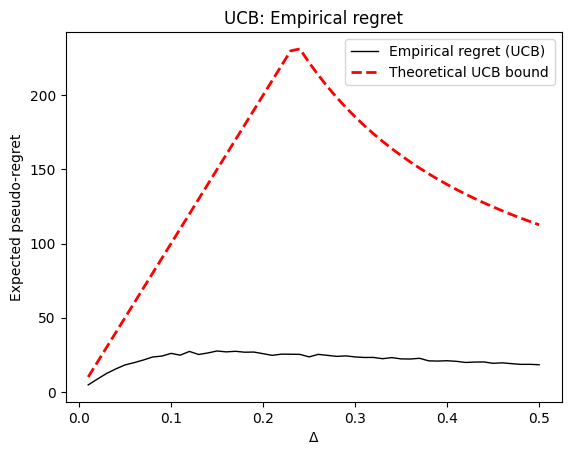

In [90]:
# ------------------------------------------------------------
# UCB vs theoretical bound
# ------------------------------------------------------------

# Delta grid in (0, 1/2) with step h
Delta_grid = np.arange(h, 0.5 + 1e-12, h)

ucb_emp_regret = []
ucb_theo_bound = []

C = 1 + (np.pi**2) / 3   # constant term in UCB bound

for Delta in Delta_grid:

    mu_1 = 0.5
    mu_2 = 0.5 - Delta

    # Empirical regret (Monte Carlo)
    r_ucb = regret_ucb(T=T, mu_1=mu_1, mu_2=mu_2, n_sim=N)
    ucb_emp_regret.append(r_ucb)

    # --------------------------------------------------------
    # Theoretical UCB bound
    # gap-dependent bound + trivial bound
    # --------------------------------------------------------
    gap_bound = (8 * np.log(T)) / Delta + C * Delta
    trivial_bound = T * Delta

    bound = min(gap_bound, trivial_bound)
    ucb_theo_bound.append(bound)

ucb_emp_regret = np.array(ucb_emp_regret)
ucb_theo_bound = np.array(ucb_theo_bound)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure()
plt.plot(Delta_grid, ucb_emp_regret,
         color="black", linewidth=1,
         label="Empirical regret (UCB)")

plt.plot(Delta_grid, ucb_theo_bound,
         color="red", linestyle="--", linewidth=2,
         label="Theoretical UCB bound")

plt.xlabel("Δ")
plt.ylabel("Expected pseudo-regret")
plt.title(f"UCB: Empirical regret")
plt.legend()
plt.show()


<a id='4'></a>
# 5. Comparaison UCB vs ETC

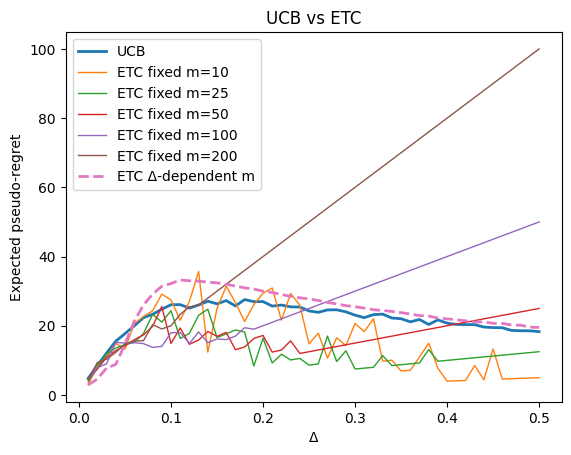

In [91]:
# ------------------------------------------------------------
# Compare UCB vs ETC for fixed m and Delta-dependent m
# ------------------------------------------------------------


# Grid Delta in (0, 1/2]
Delta_grid = np.arange(h, 0.5 + 1e-12, h)

m_fixed_list = [10, 25, 50, 100, 200]

# Containers
reg_ucb = np.zeros_like(Delta_grid, dtype=float)
reg_etc_dep = np.zeros_like(Delta_grid, dtype=float)
reg_etc_fixed = {m: np.zeros_like(Delta_grid, dtype=float) for m in m_fixed_list}

for i, Delta in enumerate(Delta_grid):
    mu_1 = 0.5
    mu_2 = 0.5 - Delta

    # -------------------------
    # UCB
    # -------------------------
    reg_ucb[i] = regret_ucb(T=T, mu_1=mu_1, mu_2=mu_2, n_sim=N)

    # -------------------------
    # ETC with fixed m
    # (ensure feasibility 2m <= T)
    # -------------------------
    for m in m_fixed_list:
        m_eff = min(m, T // 2)
        reg_etc_fixed[m][i] = regret_etc(m=m_eff, T=T, mu_1=mu_1, mu_2=mu_2, n_sim=N)

    # -------------------------
    # ETC with Delta-dependent m
    # guards: log positive + feasibility + integer
    # -------------------------
    val = (T * Delta**2) / 2
    if val <= 1.0:
        m_dep = 1
    else:
        m_dep = int(np.ceil((2 / (Delta**2)) * np.log(val)))

    m_dep = max(1, min(m_dep, T // 2))
    reg_etc_dep[i] = regret_etc(m=m_dep, T=T, mu_1=mu_1, mu_2=mu_2, n_sim=N)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure()

plt.plot(Delta_grid, reg_ucb, linewidth=2, label="UCB")

for m in m_fixed_list:
    plt.plot(Delta_grid, reg_etc_fixed[m], linewidth=1, label=f"ETC fixed m={m}")

plt.plot(Delta_grid, reg_etc_dep, linewidth=2, linestyle="--", label="ETC Δ-dependent m")

plt.xlabel("Δ")
plt.ylabel("Expected pseudo-regret")
plt.title(f"UCB vs ETC")
plt.legend()
plt.show()